In [12]:
import numpy as np
import os
import time
from arena_api.system import system
from ppadb.client import Client as AdbClient

# --- CONFIGURACIÓN ---
SAVE_DIR = r"D:\Multimodal_DB"
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

def capture_pair(samsung, device, timestamp):
    """Función interna para disparar y guardar un par de imágenes"""
    try:
        # 1. Disparar Samsung
        samsung.shell("input keyevent 27")
        
        # 2. Capturar Lucid ToF inmediatamente
        buffer = device.get_buffer()
        raw_data = np.ctypeslib.as_array(buffer.pdata, shape=(buffer.height, buffer.width))
        
        # Guardar ToF
        np.save(os.path.join(SAVE_DIR, f"tof_{timestamp}.npy"), raw_data)
        device.requeue_buffer(buffer)
        
        print(f"   [+] ToF guardado: tof_{timestamp}.npy")
        
        # 3. Esperar y traer foto del Samsung
        time.sleep(2.5) 
        last_file = samsung.shell("ls -t /sdcard/DCIM/Camera/ | head -1").strip()
        if last_file:
            samsung.pull(f"/sdcard/DCIM/Camera/{last_file}", os.path.join(SAVE_DIR, f"rgb_{timestamp}.jpg"))
            print(f"   [+] RGB guardado: rgb_{timestamp}.jpg")
        
        return True
    except Exception as e:
        print(f"   [!] Error en captura: {e}")
        return False

def iniciar_recoleccion():
    # Inicializar dispositivos
    client = AdbClient(host="127.0.0.1", port=5037)
    phones = client.devices()
    lucid_devs = system.create_device()

    if not phones or not lucid_devs:
        print("❌ Error: Asegúrate de que ambos dispositivos estén conectados.")
        return

    samsung = phones[0]
    device = lucid_devs[0]
    
    # Configurar cámara ToF
    nodemap = device.nodemap
    nodemap.get_node('PixelFormat').value = 'Coord3D_ABC16'
    
    print("📸 Abriendo cámara en Samsung...")
    samsung.shell("am start -a android.media.action.IMAGE_CAPTURE")
    time.sleep(2)
    
    device.start_stream()
    
    print("\n--- 🚀 MODO RECOLECCIÓN ACTIVO ---")
    print("Presiona ENTER para capturar un par de imágenes.")
    print("Escribe 'salir' y presiona ENTER para terminar.\n")

    contador = 0
    try:
        while True:
            entrada = input(f"Captura #{contador + 1} > Presiona Enter (o 'salir'): ").lower()
            
            if entrada == 'salir':
                break
            
            ts = int(time.time())
            exito = capture_pair(samsung, device, ts)
            
            if exito:
                contador += 1
                print(f"✨ ¡Hecho! Total capturado: {contador}\n")
                
    finally:
        device.stop_stream()
        system.destroy_device(device)
        print(f"\n✅ Sesión finalizada. Se guardaron {contador} pares de imágenes en {SAVE_DIR}")

# Lanzar la sesión
iniciar_recoleccion()

📸 Abriendo cámara en Samsung...

--- 🚀 MODO RECOLECCIÓN ACTIVO ---
Presiona ENTER para capturar un par de imágenes.
Escribe 'salir' y presiona ENTER para terminar.



Captura #1 > Presiona Enter (o 'salir'):  


   [+] ToF guardado: tof_1777331798.npy
   [+] RGB guardado: rgb_1777331798.jpg
✨ ¡Hecho! Total capturado: 1



Captura #2 > Presiona Enter (o 'salir'):  


   [+] ToF guardado: tof_1777331823.npy
   [+] RGB guardado: rgb_1777331823.jpg
✨ ¡Hecho! Total capturado: 2



Captura #3 > Presiona Enter (o 'salir'):  


   [+] ToF guardado: tof_1777331828.npy
   [+] RGB guardado: rgb_1777331828.jpg
✨ ¡Hecho! Total capturado: 3



Captura #4 > Presiona Enter (o 'salir'):  salir



✅ Sesión finalizada. Se guardaron 3 pares de imágenes en D:\Multimodal_DB


Dimensiones de la imagen: (480, 640)
Valor máximo (distancia): 255


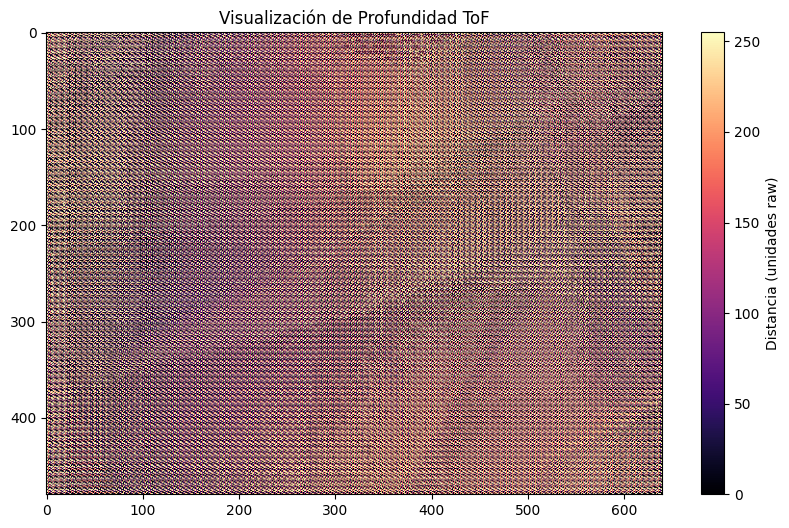

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Carga el archivo (usa el timestamp de tu éxito anterior)
data = np.load(r"D:\Multimodal_DB\tof_1777331045.npy")

print(f"Dimensiones de la imagen: {data.shape}")
print(f"Valor máximo (distancia): {np.max(data)}")

# Visualización rápida
plt.figure(figsize=(10, 6))
plt.imshow(data, cmap='magma')
plt.title("Visualización de Profundidad ToF")
plt.colorbar(label="Distancia (unidades raw)")
plt.show()